In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import preprocess_fun as fun

from geomstats.geometry.pre_shape import PreShapeSpace
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.learning.incremental_frechet_mean import IncrementalFrechetMean

In [16]:
hammer_data = scipy.io.loadmat('Hammer_Shapes.mat') 
hammers = np.stack([hammer_data['XX'],hammer_data['YY']], axis=-1)
hammer_uni = fun.obj_align(fun.unify(hammers))

In [17]:
k_landmark = 100
m_ambient = 2
preshape = PreShapeSpace(k_landmark, m_ambient)
preshape.equip_with_group_action('rotations')
preshape.equip_with_quotient()

hammer_preshape = preshape.projection(hammer_uni)

mean_frechet = FrechetMean(preshape)
mean_incremental = IncrementalFrechetMean(preshape)

hammer_mean_frechet = mean_frechet.fit(hammer_preshape).estimate_
hammer_mean_incremental = mean_incremental.fit(hammer_preshape).estimate_
hammer_mean_recursive = fun.Rec_Frechet_mean_geom(hammer_uni)



(-0.14180841135816735,
 0.186232176068513,
 -0.07003973470209826,
 0.07828923098420211)

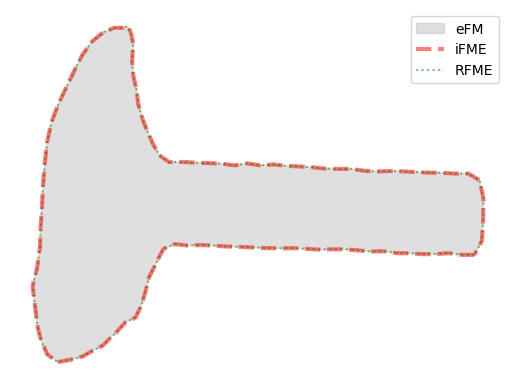

In [18]:
plt.fill(hammer_mean_frechet[:,0], hammer_mean_frechet[:,1], color = 'silver', alpha = 0.5, label = 'eFM')
plt.plot(hammer_mean_incremental[:,0], hammer_mean_incremental[:,1], linestyle='--', color = 'r', alpha = 0.5, linewidth = 3, label = 'iFME')
plt.plot(hammer_mean_recursive[:,0], hammer_mean_recursive[:,1], linestyle=':', color = 'g', alpha = 0.5, label = 'RFME')
plt.legend()
plt.axis('off')

In [19]:
eFM_TE = 0
iFME_TE = 0
RFME_TE = 0
for i in range(hammer_preshape.shape[0]):
    eFM_TE += preshape.quotient.metric.dist(hammer_mean_frechet, hammer_preshape[i])
    iFME_TE += preshape.quotient.metric.dist(hammer_mean_incremental, hammer_preshape[i])
    RFME_TE += preshape.quotient.metric.dist(hammer_mean_recursive, hammer_preshape[i])

In [20]:
print('eFM:', eFM_TE, '\niFME:', iFME_TE, '\nRFME:', RFME_TE)

eFM: 1.202566210846781 
iFME: 1.2025516509286558 
RFME: 1.202607402805974


In [21]:
print('eFM:', fun.SSE(hammer_mean_frechet, hammer_preshape), '\niFME:', fun.SSE(hammer_mean_incremental, hammer_preshape), '\nRFME:', fun.SSE(hammer_mean_recursive, hammer_preshape))

eFM: 0.1777614762939241 
iFME: 0.17776124903063964 
RFME: 0.17776129595666249
